In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
df = pd.read_csv(r'C:\D_Drive\B.E\Sem-VII\LP-V\DL\letter+recognition\letter-recognition.data', header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [4]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

In [5]:
class OCRModel(nn.Module):
    def __init__(self):
        super(OCRModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 26)
        )
    
    def forward(self, x):
        return self.fc(x)

In [6]:
model = OCRModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

In [7]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
model.eval()

Epoch [10/100], Loss: 3.1395
Epoch [20/100], Loss: 2.9521
Epoch [30/100], Loss: 2.6767
Epoch [40/100], Loss: 2.3444
Epoch [50/100], Loss: 2.0157
Epoch [60/100], Loss: 1.7334
Epoch [70/100], Loss: 1.5080
Epoch [80/100], Loss: 1.3347
Epoch [90/100], Loss: 1.2025
Epoch [100/100], Loss: 1.0999


OCRModel(
  (fc): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=26, bias=True)
  )
)

In [8]:
with torch.no_grad():
    predicted  = model(X_test)
    predicted_label = torch.argmax(predicted, dim=1)
    predicted_values = label_encoder.inverse_transform(predicted_label.numpy())
    print(predicted_values)
    print(criterion(predicted, y_test).item())

['Z' 'Y' 'A' ... 'O' 'Y' 'Y']
1.0855491161346436


In [9]:
for i in range(5):
    print(f'Predicted: {predicted_values[i]}, Actual: {label_encoder.inverse_transform([y_test[i].item()])[0]}')

Predicted: Z, Actual: T
Predicted: Y, Actual: L
Predicted: A, Actual: A
Predicted: E, Actual: E
Predicted: Q, Actual: Q


[[133   0   0   2   0   0   0   0   0   2   2   0   2   0   0   0   0   0
    3   0   0   0   2   2   1   0]
 [  0 125   0   5   0   0   0   4   0   0   1   0   0   0   0   5   2   8
    0   0   0   0   0   3   0   0]
 [  0   0  96   0   6   2  10   2   0   0  13   0   0   0   2   0   2   0
    0   1   2   0   1   0   0   0]
 [  2   3   0 126   0   0   0   2   0   1   0   0   3   0   1   2   0   4
    2   2   0   0   0   4   0   4]
 [  0   2   2   0 102   0   8   0   0   0   2   0   0   0   0   0   4   1
    2   2   0   0   0   1   0  15]
 [  0   3   2   2   0  96   8   1   0   0   0   0   0   0   0   7   1   1
    5   6   0   1   2   1   2   2]
 [  1   5  39   1   2   0  66   2   0   0  10   2   0   0   0   0  14   7
    4   0   0   1   5   1   0   0]
 [  0   5   0  11   0   0   0  52   0   1  12   0  11   5  13   2   4  13
    0   1   9   0   0   3   2   0]
 [  0   1   1   2   1   1   0   0 115   6   0   1   0   0   0   1   1   2
    8   0   0   0   0   4   2   0]
 [  1   0   0   4  

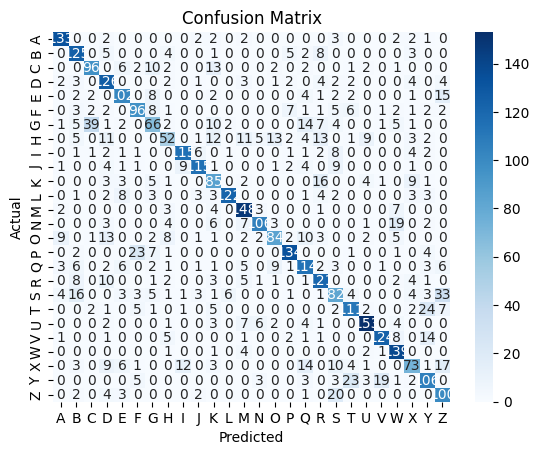

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(label_encoder.inverse_transform(y_test.numpy()), predicted_values)
print(cm)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(label_encoder.inverse_transform(y_test.numpy()), predicted_values))
print(f'Accuracy: {accuracy_score(label_encoder.inverse_transform(y_test.numpy()), predicted_values):.4f}')

              precision    recall  f1-score   support

           A       0.85      0.89      0.87       149
           B       0.69      0.82      0.75       153
           C       0.67      0.70      0.69       137
           D       0.62      0.81      0.70       156
           E       0.72      0.72      0.72       141
           F       0.70      0.69      0.69       140
           G       0.56      0.41      0.47       160
           H       0.57      0.36      0.44       144
           I       0.83      0.79      0.81       146
           J       0.85      0.77      0.81       149
           K       0.54      0.65      0.59       130
           L       0.93      0.79      0.85       155
           M       0.75      0.88      0.81       168
           N       0.84      0.70      0.77       151
           O       0.72      0.58      0.64       145
           P       0.84      0.77      0.81       173
           Q       0.63      0.69      0.66       166
           R       0.65    